# ASH market-making pattern research

This notebook focuses only on `ASH_COATED_OSMIUM` in `prices_round_1_day_0.csv`.

The goal is to make the hidden market-making pattern visible with tables and plots:
- verify whether the top-of-book midpoint already equals the reported `mid_price`,
- inspect the spread/state distribution,
- test whether top-level volume imbalance predicts the next repricing direction,
- translate the pattern into concrete market-making implications.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')


In [2]:
raw = pd.read_csv('prices_round_1_day_0.csv', sep=';')

ash = (
    raw.loc[raw['product'] == 'ASH_COATED_OSMIUM']
    .sort_values('timestamp')
    .reset_index(drop=True)
    .copy()
)

# Ignore malformed rows where the feed reports a zero mid.
ash = ash.loc[ash['mid_price'] > 0].reset_index(drop=True)

ash['spread'] = ash['ask_price_1'] - ash['bid_price_1']
ash['center'] = (ash['ask_price_1'] + ash['bid_price_1']) / 2
ash['center_minus_mid'] = ash['center'] - ash['mid_price']
ash['imbalance_diff'] = ash['bid_volume_1'] - ash['ask_volume_1']
ash['imbalance_ratio'] = ash['imbalance_diff'] / (ash['bid_volume_1'] + ash['ask_volume_1'])
ash['imbalance_sign'] = np.sign(ash['imbalance_diff'])
ash['next_mid'] = ash['mid_price'].shift(-1)
ash['next_ret'] = ash['next_mid'] - ash['mid_price']
ash['next_bid_move'] = ash['bid_price_1'].shift(-1) - ash['bid_price_1']
ash['next_ask_move'] = ash['ask_price_1'].shift(-1) - ash['ask_price_1']
ash['next_spread'] = ash['spread'].shift(-1)
ash['bid_gap'] = ash['bid_price_1'] - ash['bid_price_2']
ash['ask_gap'] = ash['ask_price_2'] - ash['ask_price_1']

ash.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,imbalance_diff,imbalance_ratio,imbalance_sign,next_mid,next_ret,next_bid_move,next_ask_move,next_spread,bid_gap,ask_gap
0,0,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,"10,013.000",...,NaN,NaN,NaN,"10,003.000",-10.000,NaN,-2.000,16.000,NaN,NaN
1,0,100,ASH_COATED_OSMIUM,"9,995.000",13.000,NaN,NaN,NaN,NaN,"10,011.000",...,0.000,0.000,0.000,"10,003.500",0.500,-1.000,2.000,19.000,NaN,2.000
2,0,200,ASH_COATED_OSMIUM,"9,994.000",13.000,"9,992.000",21.000,NaN,NaN,"10,013.000",...,-8.000,-0.235,-1.000,"10,002.000",-1.500,0.000,-3.000,16.000,2.000,NaN
3,0,300,ASH_COATED_OSMIUM,"9,994.000",11.000,"9,992.000",23.000,NaN,NaN,"10,010.000",...,0.000,0.000,0.000,"10,002.000",0.000,0.000,0.000,16.000,2.000,3.000
4,0,400,ASH_COATED_OSMIUM,"9,994.000",13.000,"9,991.000",23.000,NaN,NaN,"10,010.000",...,0.000,0.000,0.000,"10,002.000",0.000,0.000,0.000,16.000,3.000,2.000


## 1. Sanity check: is there hidden fair value inside the spread?

If `mid_price` already equals the top-of-book center, then the hidden signal is not an unobserved fair value inside the spread. In that case we should look for information in book shape and quote transitions instead.

In [3]:
center_check = ash[['mid_price', 'bid_price_1', 'ask_price_1', 'center', 'center_minus_mid']].dropna().copy()

print('Rows with both best quotes present:', len(center_check))
print(center_check['center_minus_mid'].describe())
print('\nDistinct center - mid values:')
print(center_check['center_minus_mid'].value_counts().sort_index())

center_check.head(10)

Rows with both best quotes present: 9232
count   9,232.000
mean        0.000
std         0.000
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         0.000
Name: center_minus_mid, dtype: float64

Distinct center - mid values:
center_minus_mid
0.000    9232
Name: count, dtype: int64


,mid_price,bid_price_1,ask_price_1,center,center_minus_mid
1,"10,003.000","9,995.000","10,011.000","10,003.000",0.000
2,"10,003.500","9,994.000","10,013.000","10,003.500",0.000
3,"10,002.000","9,994.000","10,010.000","10,002.000",0.000
4,"10,002.000","9,994.000","10,010.000","10,002.000",0.000
5,"10,002.000","9,994.000","10,010.000","10,002.000",0.000
6,"10,000.500","9,991.000","10,010.000","10,000.500",0.000
7,"10,000.500","9,991.000","10,010.000","10,000.500",0.000
8,"10,002.500","9,993.000","10,012.000","10,002.500",0.000
9,"10,000.000","9,992.000","10,008.000","10,000.000",0.000
10,"10,001.000","9,993.000","10,009.000","10,001.000",0.000


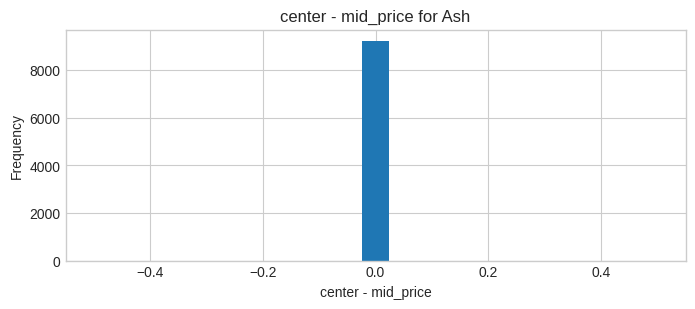

In [4]:
fig, ax = plt.subplots(figsize=(8, 3))
center_check['center_minus_mid'].plot(kind='hist', bins=21, ax=ax)
ax.set_title('center - mid_price for Ash')
ax.set_xlabel('center - mid_price')
plt.show()

## 2. Spread regime distribution

This helps us see which quote states are normal versus transitional.

In [5]:
spread_counts = ash['spread'].value_counts().sort_index().rename('count').to_frame()
spread_counts['share'] = spread_counts['count'] / len(ash)
spread_counts

,count,share
spread,,
5.000,58,0.006
6.000,130,0.013
7.000,51,0.005
8.000,32,0.003
9.000,111,0.011
10.000,193,0.019
11.000,104,0.010
12.000,37,0.004
13.000,52,0.005


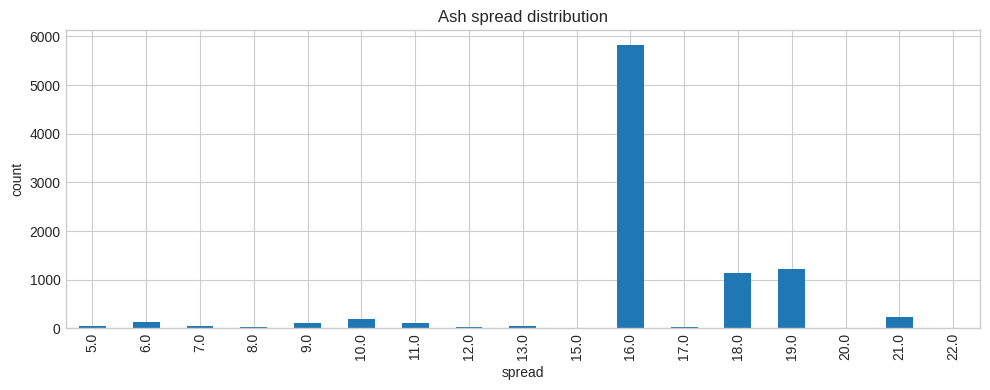

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
spread_counts['count'].plot(kind='bar', ax=ax)
ax.set_title('Ash spread distribution')
ax.set_xlabel('spread')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

## 3. Hidden pattern: top-level imbalance predicts the next repricing direction

Define `imbalance_diff = bid_volume_1 - ask_volume_1`.

Interpretation:
- positive imbalance means the bid is stronger and the ask side is thinner,
- negative imbalance means the ask is stronger and the bid side is thinner.

If this pattern is real, the next mid move should follow the sign of the imbalance.

In [7]:
imbalance_summary = (
    ash.dropna(subset=['next_ret'])
    .groupby('imbalance_sign')
    .agg(
        count=('next_ret', 'size'),
        mean_next_ret=('next_ret', 'mean'),
        up_prob=('next_ret', lambda s: (s > 0).mean()),
        down_prob=('next_ret', lambda s: (s < 0).mean()),
        flat_prob=('next_ret', lambda s: (s == 0).mean()),
    )
)

imbalance_summary.index = imbalance_summary.index.map({-1.0: 'negative', 0.0: 'zero', 1.0: 'positive'})
imbalance_summary

,count,mean_next_ret,up_prob,down_prob,flat_prob
imbalance_sign,,,,,
negative,1551,-1.866,0.089,0.854,0.057
zero,6105,-0.006,0.282,0.288,0.430
positive,1575,1.884,0.853,0.100,0.047


In [8]:
diff_table = (
    ash.dropna(subset=['next_ret'])
    .groupby('imbalance_diff')
    .agg(
        count=('next_ret', 'size'),
        mean_next_ret=('next_ret', 'mean'),
        up_prob=('next_ret', lambda s: (s > 0).mean()),
        down_prob=('next_ret', lambda s: (s < 0).mean()),
    )
)

diff_table.loc[(diff_table['count'] >= 20)].head(20)

,count,mean_next_ret,up_prob,down_prob
imbalance_diff,,,,
-20.000,28,-2.071,0.107,0.821
-19.000,36,-1.361,0.167,0.750
-18.000,56,-2.107,0.125,0.857
-17.000,77,-1.442,0.143,0.779
-16.000,92,-1.120,0.098,0.870
-15.000,116,-1.483,0.078,0.819
-14.000,109,-1.394,0.083,0.862
-13.000,108,-1.431,0.093,0.815
-12.000,133,-1.282,0.075,0.865


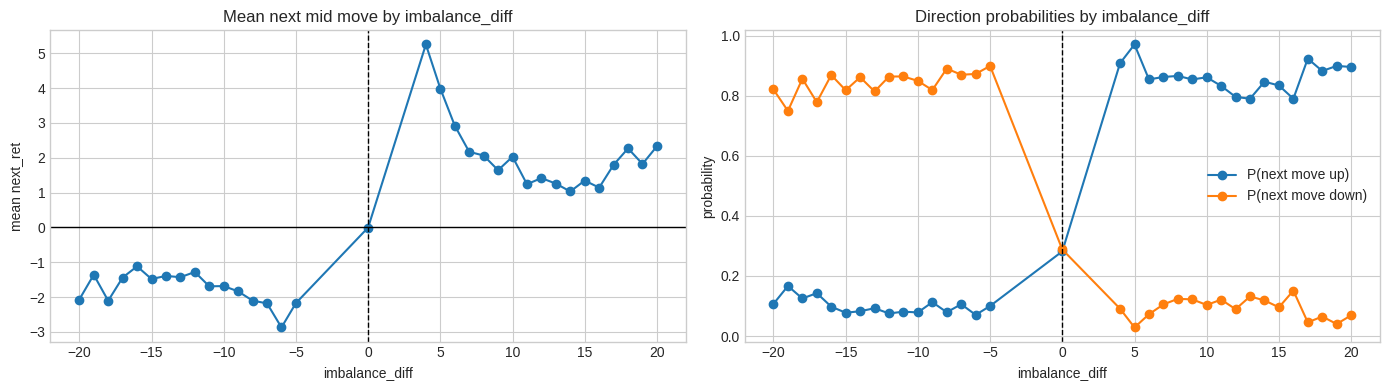

In [ ]:
diff_plot = diff_table.loc[diff_table['count'] >= 20].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(diff_plot['imbalance_diff'], diff_plot['mean_next_ret'], marker='o')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].axvline(0, color='black', linewidth=1, linestyle='--')￼
image.png
￼
￼
image.png
￼
￼
image.png
axes[0].set_title('Mean next mid move by imbalance_diff')
axes[0].set_xlabel('imbalance_diff')
axes[0].set_ylabel('mean next_ret')

axes[1].plot(diff_plot['imbalance_diff'], diff_plot['up_prob'], marker='o', label='P(next move up)')
axes[1].plot(diff_plot['imbalance_diff'], diff_plot['down_prob'], marker='o', label='P(next move down)')
axes[1].axvline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Direction probabilities by imbalance_diff')
axes[1].set_xlabel('imbalance_diff')
axes[1].set_ylabel('probability')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. State machine view: spread plus imbalance

This section makes the market-making states explicit.

We expect:
- `spread = 16` and `imbalance_diff = 0` to be the neutral two-sided quoting regime,
- `spread = 18/19` with nonzero imbalance to be directional transition states,
- `spread = 21` with zero imbalance to be a symmetric compression state.

In [10]:
state_counts = (
    ash.dropna(subset=['spread'])
    .groupby(['spread', 'imbalance_diff'])
    .size()
    .rename('count')
    .sort_values(ascending=False)
)

state_counts.head(20)

spread  imbalance_diff
16.000  0.000             5834
21.000  0.000              228
18.000  14.000              67
19.000  -15.000             65
18.000  13.000              62
19.000  -14.000             62
        13.000              60
        12.000              60
        -12.000             59
        15.000              59
18.000  11.000              59
19.000  -9.000              58
18.000  -13.000             58
19.000  11.000              56
        -11.000             56
18.000  -12.000             55
        12.000              52
        15.000              51
19.000  -10.000             51
18.000  -16.000             51
Name: count, dtype: int64

In [11]:
state_effects = (
    ash.dropna(subset=['spread', 'next_ret'])
    .groupby(['spread', 'imbalance_sign'])
    .agg(
        count=('next_ret', 'size'),
        mean_next_ret=('next_ret', 'mean'),
        next_bid_move=('next_bid_move', 'mean'),
        next_ask_move=('next_ask_move', 'mean'),
        narrow_prob=('next_spread', lambda s: (s < ash.loc[s.index, 'spread']).mean()),
        widen_prob=('next_spread', lambda s: (s > ash.loc[s.index, 'spread']).mean()),
    )
    .sort_values(['spread', 'imbalance_sign'])
)

state_effects.loc[state_effects['count'] >= 20]

count  mean_next_ret  next_bid_move  next_ask_move  \
spread imbalance_sign                                                       
5.000  1.000              57          5.684         -0.309         11.070   
6.000  -1.000             58         -5.103         -9.877          0.200   
       1.000              68          5.081          0.106         10.308   
7.000  -1.000             49         -4.735         -9.283         -0.383   
8.000  1.000              32          6.641          2.533         10.800   
9.000  -1.000             20         -7.200         -9.850         -3.056   
       1.000              91          3.445         -0.193          7.195   
10.000 -1.000            108         -3.245         -6.104          0.347   
       1.000              85          3.247          0.139          6.162   
11.000 -1.000            104         -2.697         -5.299         -0.196   
12.000 1.000              37          4.081          2.111          6.083   
13.000 -1.000             52         -4.135         -5.750         -2.216   
16.000 0.000            5834         -0.020         -0.107          0.067   
17.000 0.000              21          0.405          0.000          0.048   
18.000 -1.000            549         -1.195         -0.423         -2.079   
       1.000             596          1.091          2.128          0.120   
19.000 -1.000            611         -1.179          0.109         -2.653   
       1.000             609          1.140          2.663         -0.308   
21.000 0.000             228          0.215          2.412         -2.398   

                       narrow_prob  widen_prob  
spread imbalance_sign                           
5.000  1.000                 0.000       0.965  
6.000  -1.000                0.000       0.897  
       1.000                 0.000       0.897  
7.000  -1.000                0.020       0.857  
8.000  1.000                 0.000       0.875  
9.000  -1.000                0.100       0.800  
       1.000                 0.000       0.912  
10.000 -1.000                0.019       0.880  
       1.000                 0.047       0.812  
11.000 -1.000                0.038       0.808  
12.000 1.000                 0.081       0.865  
13.000 -1.000                0.019       0.962  
16.000 0.000                 0.080       0.264  
17.000 0.000                 0.429       0.524  
18.000 -1.000                0.628       0.153  
       1.000                 0.666       0.144  
19.000 -1.000                0.751       0.020  
       1.000                 0.813       0.020  
21.000 0.000                 0.895       0.000

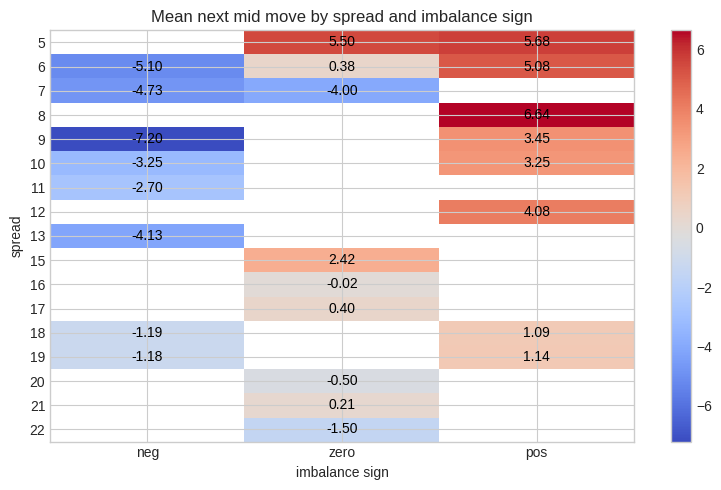

In [12]:
heatmap_data = (
    ash.dropna(subset=['next_ret'])
    .pivot_table(
        index='spread',
        columns='imbalance_sign',
        values='next_ret',
        aggfunc='mean'
    )
)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_data, cmap='coolwarm', aspect='auto')
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(['neg', 'zero', 'pos'])
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index.astype(int))
ax.set_title('Mean next mid move by spread and imbalance sign')
ax.set_xlabel('imbalance sign')
ax.set_ylabel('spread')

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f'{value:.2f}', ha='center', va='center', color='black')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 5. Adverse selection view for a market maker

If the imbalance is positive, the ask side is thinner. A passive ask is the weak-side quote and is more likely to get run over by an upward repricing.

If the imbalance is negative, the bid side is thinner. A passive bid is the weak-side quote and is more likely to get run over by a downward repricing.

In [13]:
adverse = ash.dropna(subset=['next_ret']).copy()
adverse['weak_side'] = np.where(
    adverse['imbalance_diff'] > 0,
    'ask',
    np.where(adverse['imbalance_diff'] < 0, 'bid', 'flat')
)
adverse['weak_side_adverse'] = np.where(
    adverse['weak_side'] == 'ask',
    adverse['next_ret'] > 0,
    np.where(adverse['weak_side'] == 'bid', adverse['next_ret'] < 0, np.nan)
)

adverse.groupby('weak_side').agg(
    count=('next_ret', 'size'),
    mean_next_ret=('next_ret', 'mean'),
    adverse_rate=('weak_side_adverse', 'mean')
)

,count,mean_next_ret,adverse_rate
weak_side,,,
ask,1575,1.884,0.853
bid,1551,-1.866,0.854
flat,6859,-0.011,NaN


In [14]:
gap_summary = pd.DataFrame({
    'bid_gap_mean_next_ret': ash.groupby('bid_gap')['next_ret'].mean(),
    'ask_gap_mean_next_ret': ash.groupby('ask_gap')['next_ret'].mean(),
}).sort_index()

gap_summary

,bid_gap_mean_next_ret,ask_gap_mean_next_ret
2.000,0.507,-0.473
3.000,0.124,-0.142
4.000,-5.833,2.333
5.000,-2.500,NaN
6.000,-2.866,2.831
7.000,NaN,3.253
8.000,-3.357,NaN
9.000,-5.398,3.554
10.000,-5.104,5.348
11.000,NaN,5.841


## 6. Market-making interpretation

What the notebook should convince you of:

1. `mid_price` is already the book center when both best quotes are present, so there is no hidden fair-value edge inside the spread.
2. The real hidden pattern is a state machine in the top-of-book shape.
3. Neutral regime: `spread = 16`, `imbalance_diff = 0`.
4. Directional regime: `spread = 18/19` and nonzero imbalance. The sign of the imbalance strongly predicts the next repricing direction.
5. Compression regime: `spread = 21`, `imbalance_diff = 0`, which tends to narrow inward.

How to use this in market making:
- quote both sides most confidently in the neutral symmetric regime,
- skew toward the strong side when imbalance is nonzero,
- widen or cancel the weak-side quote to reduce adverse selection,
- treat wider spread states as transition states, not automatically as better spread-capture opportunities.
